## VII. Model Implementation and Comparison

We implement five different classification models to determine which best predicts the **novelty tier** (0–3) of patent texts using TF-IDF vectorized and chi² selected features.

### 1. Multinomial Naive Bayes
A probabilistic classifier based on Bayes' Theorem, assuming word independence. Fast and effective for high-dimensional text data.

### 2. Logistic Regression
A linear probabilistic classifier that estimates the probability of each novelty tier using the logistic function. Serves as a strong interpretable baseline.

### 3. Support Vector Machine (LinearSVC)
A highly efficient linear SVM variant optimized for large-scale, high-dimensional text classification tasks like TF-IDF features.

### 4. Random Forest
An ensemble of decision trees trained on random data subsets, combining their outputs to reduce overfitting and improve accuracy.

### 5. Gradient Boosting
An ensemble that builds trees sequentially, where each tree corrects the errors of the previous, resulting in a strong predictive model.

---

### 6. XGBoost
An optimized gradient boosting framework with built-in L1/L2 regularization, parallel processing, and superior speed — known for winning ML competitions.

## Shared Setup — Libraries, Data, Feature Extraction & Preprocessing

All five models share the same dataset, TF-IDF vectorization, chi² feature selection, and train/test split to ensure a fair and consistent comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score,
                              precision_score, recall_score)

In [2]:
df = pd.read_csv("/content/sample_data/final_patent_dataset_balanced.csv")

# Drop rows where clean_text or novelty tier is NaN
df = df.dropna(subset=["clean_text", "novelty tier"])

# Ensure novelty tier is integer
df["novelty tier"] = df["novelty tier"].astype(int)

# Re-balance after dropping to restore equal class sizes
from sklearn.utils import resample
target_size = df["novelty tier"].value_counts().min()
df = (df.groupby("novelty tier", group_keys=False)
        .apply(lambda x: resample(x, replace=False, n_samples=target_size, random_state=42)))
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset Shape:", df.shape)
print("Class Distribution (after re-balancing):")
print(df["novelty tier"].value_counts().sort_index())


Dataset Shape: (5000, 2)
Class Distribution (after re-balancing):
novelty tier
0    1250
1    1250
2    1250
3    1250
Name: count, dtype: int64


### TF-IDF Vectorization

TF-IDF converts patent text into numerical features by weighing how important each word is within a document relative to the entire corpus.

Key parameters used:
- `max_features=10000` – top 10,000 most informative terms
- `ngram_range=(1,3)` – unigrams, bigrams, and trigrams to capture phrases
- `min_df=2` – ignore terms that appear in fewer than 2 documents
- `max_df=0.9` – ignore terms that appear in more than 90% of documents
- `sublinear_tf=True` – apply log normalization to term frequencies

In [3]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X = vectorizer.fit_transform(df["clean_text"])
y = df["novelty tier"]

print("TF-IDF shape:", X.shape)

TF-IDF shape: (5000, 10000)


### Chi² Feature Selection

`SelectKBest` with the chi² statistic is applied to retain the **top 3000 most informative features**, reducing dimensionality while preserving the features most correlated with novelty tier labels.

In [4]:
selector = SelectKBest(chi2, k=3000)
X = selector.fit_transform(X, y)

print("After feature selection:", X.shape)

After feature selection: (5000, 3000)


### Train-Test Split

The dataset is split into **80% training** and **20% testing**.  
`stratify=y` ensures class proportions are preserved in both splits.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (4000, 3000)
Test : (1000, 3000)


---

## 1. Multinomial Naive Bayes Implementation

In this section, we implement Multinomial Naive Bayes — a probabilistic classifier that works well with discrete, count-based text features like TF-IDF.

### Step 1: Model Training

`MultinomialNB()` is initialized with default parameters and trained directly on the TF-IDF feature matrix.  
No additional hyperparameter tuning is needed — it learns the word likelihood per novelty tier efficiently.

In [6]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

### Step 2: Making Predictions

Predictions are made on the unseen test set.

In [7]:
y_pred_nb = nb_model.predict(X_test)

### Step 3: Model Evaluation

Performance is evaluated using:
- **Accuracy** – overall percentage of correct predictions
- **Macro F1 Score** – average F1 across all tiers with equal weight per class
- **Classification Report** – per-class Precision, Recall, and F1
- **Confusion Matrix** – shows misclassification patterns across tiers

In [8]:
nb_acc   = accuracy_score(y_test, y_pred_nb)
nb_macro = f1_score(y_test, y_pred_nb, average="macro")
nb_prec  = precision_score(y_test, y_pred_nb, average="weighted")
nb_rec   = recall_score(y_test, y_pred_nb, average="weighted")

print("Multinomial Naive Bayes Results")
print(f"Accuracy   : {nb_acc:.4f}")
print(f"Macro F1   : {nb_macro:.4f}")
print(f"Precision  : {nb_prec:.4f}")
print(f"Recall     : {nb_rec:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Multinomial Naive Bayes Results
Accuracy   : 0.5840
Macro F1   : 0.5811
Precision  : 0.5847
Recall     : 0.5840

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.52      0.58       250
           1       0.43      0.43      0.43       250
           2       0.55      0.59      0.57       250
           3       0.70      0.80      0.75       250

    accuracy                           0.58      1000
   macro avg       0.58      0.58      0.58      1000
weighted avg       0.58      0.58      0.58      1000

Confusion Matrix:
[[130  61  40  19]
 [ 50 107  61  32]
 [  9  59 147  35]
 [  7  22  21 200]]


---

## 2. Logistic Regression Implementation

In this section, we implement Logistic Regression — a linear model that estimates class probabilities using the logistic function.

### Step 1: Model Training

Key parameter:
- `max_iter=3000` — increased from the default to ensure the solver fully converges on the high-dimensional TF-IDF feature space.

In [9]:
lr_model = LogisticRegression(max_iter=3000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

### Step 2: Making Predictions

In [10]:
y_pred_lr = lr_model.predict(X_test)

### Step 3: Model Evaluation

In [11]:
lr_acc   = accuracy_score(y_test, y_pred_lr)
lr_macro = f1_score(y_test, y_pred_lr, average="macro")
lr_prec  = precision_score(y_test, y_pred_lr, average="weighted")
lr_rec   = recall_score(y_test, y_pred_lr, average="weighted")

print("Logistic Regression Results")
print(f"Accuracy   : {lr_acc:.4f}")
print(f"Macro F1   : {lr_macro:.4f}")
print(f"Precision  : {lr_prec:.4f}")
print(f"Recall     : {lr_rec:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Results
Accuracy   : 0.6970
Macro F1   : 0.6913
Precision  : 0.6904
Recall     : 0.6970

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.73      0.70       250
           1       0.60      0.48      0.54       250
           2       0.68      0.69      0.68       250
           3       0.81      0.88      0.85       250

    accuracy                           0.70      1000
   macro avg       0.69      0.70      0.69      1000
weighted avg       0.69      0.70      0.69      1000

Confusion Matrix:
[[183  42  17   8]
 [ 64 121  48  17]
 [ 17  34 172  27]
 [  8   4  17 221]]


---

## 3. Support Vector Machine (LinearSVC) Implementation

In this section, we implement `LinearSVC` — a highly efficient linear SVM optimized for large-scale text classification.

### Step 1: Model Training

`LinearSVC` is used instead of `SVC(kernel='linear')` because it is significantly **faster on high-dimensional sparse TF-IDF data** while producing equivalent results.  
It directly optimizes a linear decision boundary between novelty tier classes.

In [12]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

LinearSVC()

### Step 2: Making Predictions

In [13]:
y_pred_svm = svm_model.predict(X_test)

### Step 3: Model Evaluation

In [14]:
svm_acc   = accuracy_score(y_test, y_pred_svm)
svm_macro = f1_score(y_test, y_pred_svm, average="macro")
svm_prec  = precision_score(y_test, y_pred_svm, average="weighted")
svm_rec   = recall_score(y_test, y_pred_svm, average="weighted")

print("Support Vector Machine (LinearSVC) Results")
print(f"Accuracy   : {svm_acc:.4f}")
print(f"Macro F1   : {svm_macro:.4f}")
print(f"Precision  : {svm_prec:.4f}")
print(f"Recall     : {svm_rec:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Support Vector Machine (LinearSVC) Results
Accuracy   : 0.7820
Macro F1   : 0.7813
Precision  : 0.7819
Recall     : 0.7820

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.76      0.73       250
           1       0.66      0.62      0.64       250
           2       0.85      0.82      0.83       250
           3       0.91      0.94      0.92       250

    accuracy                           0.78      1000
   macro avg       0.78      0.78      0.78      1000
weighted avg       0.78      0.78      0.78      1000

Confusion Matrix:
[[189  55   5   1]
 [ 71 155  17   7]
 [ 10  22 204  14]
 [  1   2  13 234]]


---

## 4. Random Forest Implementation

In this section, we implement the Random Forest classifier — an ensemble of decision trees that combines predictions to reduce overfitting and improve generalization.

### Step 1: Model Training

Key parameter:
- `n_estimators=200` — builds 200 decision trees; more trees generally improve stability and accuracy

In [15]:
rf_model = RandomForestClassifier(n_estimators=200)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

### Step 2: Making Predictions

In [16]:
y_pred_rf = rf_model.predict(X_test)

### Step 3: Model Evaluation

In [17]:
rf_acc   = accuracy_score(y_test, y_pred_rf)
rf_macro = f1_score(y_test, y_pred_rf, average="macro")
rf_prec  = precision_score(y_test, y_pred_rf, average="weighted")
rf_rec   = recall_score(y_test, y_pred_rf, average="weighted")

print("Random Forest Results")
print(f"Accuracy   : {rf_acc:.4f}")
print(f"Macro F1   : {rf_macro:.4f}")
print(f"Precision  : {rf_prec:.4f}")
print(f"Recall     : {rf_rec:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy   : 0.8100
Macro F1   : 0.8093
Precision  : 0.8105
Recall     : 0.8100

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76       250
           1       0.70      0.63      0.66       250
           2       0.84      0.86      0.85       250
           3       0.98      0.95      0.96       250

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000

Confusion Matrix:
[[200  45   5   0]
 [ 65 158  25   2]
 [  8  24 215   3]
 [  1   0  12 237]]


---

## 5. Gradient Boosting Implementation

In this section, we implement Gradient Boosting — a sequential ensemble that builds trees one by one, each correcting the residual errors of the previous, resulting in a strong final model.

### Step 1: Model Training

`GradientBoostingClassifier()` is initialized with default parameters.  
It uses **decision stumps** (shallow trees) as weak learners, combining them via gradient descent optimization.

In [18]:
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

GradientBoostingClassifier()

### Step 2: Making Predictions

In [19]:
y_pred_gb = gb_model.predict(X_test)

### Step 3: Model Evaluation

In [20]:
gb_acc   = accuracy_score(y_test, y_pred_gb)
gb_macro = f1_score(y_test, y_pred_gb, average="macro")
gb_prec  = precision_score(y_test, y_pred_gb, average="weighted")
gb_rec   = recall_score(y_test, y_pred_gb, average="weighted")

print("Gradient Boosting Results")
print(f"Accuracy   : {gb_acc:.4f}")
print(f"Macro F1   : {gb_macro:.4f}")
print(f"Precision  : {gb_prec:.4f}")
print(f"Recall     : {gb_rec:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Results
Accuracy   : 0.8220
Macro F1   : 0.8217
Precision  : 0.8248
Recall     : 0.8220

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.84      0.78       250
           1       0.76      0.68      0.72       250
           2       0.90      0.84      0.87       250
           3       0.92      0.93      0.92       250

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000

Confusion Matrix:
[[209  39   2   0]
 [ 71 171   7   1]
 [  7  14 209  20]
 [  0   2  15 233]]


---

## 6. XGBoost Implementation

In this section, we implement XGBoost (Extreme Gradient Boosting) — an optimized and regularized version of Gradient Boosting known for its high accuracy, speed, and built-in L1/L2 regularization.

### Step 1: Import Required Library

We import `XGBClassifier` from the `xgboost` library.

In [21]:
import xgboost as xgb

### Step 2: Model Training

An XGBoost classifier is trained using the `multi:softmax` objective for 4-class novelty tier classification.

Key parameters:
- `n_estimators=200` – number of sequential boosting rounds
- `max_depth=6` – controls tree complexity to prevent overfitting
- `learning_rate=0.1` – contribution (shrinkage) of each tree
- `subsample=0.8` – fraction of training data used per tree (adds randomness)
- `colsample_bytree=0.8` – fraction of features used per tree
- `eval_metric="mlogloss"` – multi-class log loss used during training

In [22]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=4,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=4, ...)

### Step 3: Making Predictions

In [23]:
y_pred_xgb = xgb_model.predict(X_test)

### Step 4: Model Evaluation

In [24]:
xgb_acc   = accuracy_score(y_test, y_pred_xgb)
xgb_macro = f1_score(y_test, y_pred_xgb, average="macro")
xgb_prec  = precision_score(y_test, y_pred_xgb, average="weighted")
xgb_rec   = recall_score(y_test, y_pred_xgb, average="weighted")

print("XGBoost Results")
print(f"Accuracy   : {xgb_acc:.4f}")
print(f"Macro F1   : {xgb_macro:.4f}")
print(f"Precision  : {xgb_prec:.4f}")
print(f"Recall     : {xgb_rec:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Results
Accuracy   : 0.8820
Macro F1   : 0.8820
Precision  : 0.8840
Recall     : 0.8820

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       250
           1       0.82      0.75      0.78       250
           2       0.94      0.92      0.93       250
           3       0.99      0.96      0.98       250

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000

Confusion Matrix:
[[222  27   1   0]
 [ 55 188   7   0]
 [  2  14 231   3]
 [  0   1   8 241]]


---

## VIII. Model Comparison

All five models are compared side by side using consistent evaluation metrics computed on the same test split.

In [25]:
results_df = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression",
        "Support Vector Machine",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Accuracy":      [nb_acc,  lr_acc,  svm_acc,  rf_acc,  gb_acc,  xgb_acc],
    "Macro F1":      [nb_macro, lr_macro, svm_macro, rf_macro, gb_macro, xgb_macro],
    "Precision (w)": [nb_prec, lr_prec, svm_prec, rf_prec, gb_prec, xgb_prec],
    "Recall (w)":    [nb_rec,  lr_rec,  svm_rec,  rf_rec,  gb_rec,  xgb_rec]
}).round(4)

print("\nMODEL COMPARISON")
print(results_df.sort_values(by="Macro F1", ascending=False).to_string(index=False))


MODEL COMPARISON
                  Model  Accuracy  Macro F1  Precision (w)  Recall (w)
                XGBoost     0.882    0.8820         0.8840       0.882
      Gradient Boosting     0.822    0.8217         0.8248       0.822
          Random Forest     0.810    0.8093         0.8105       0.810
 Support Vector Machine     0.782    0.7813         0.7819       0.782
    Logistic Regression     0.697    0.6913         0.6904       0.697
Multinomial Naive Bayes     0.584    0.5811         0.5847       0.584


## Model Comparison Charts

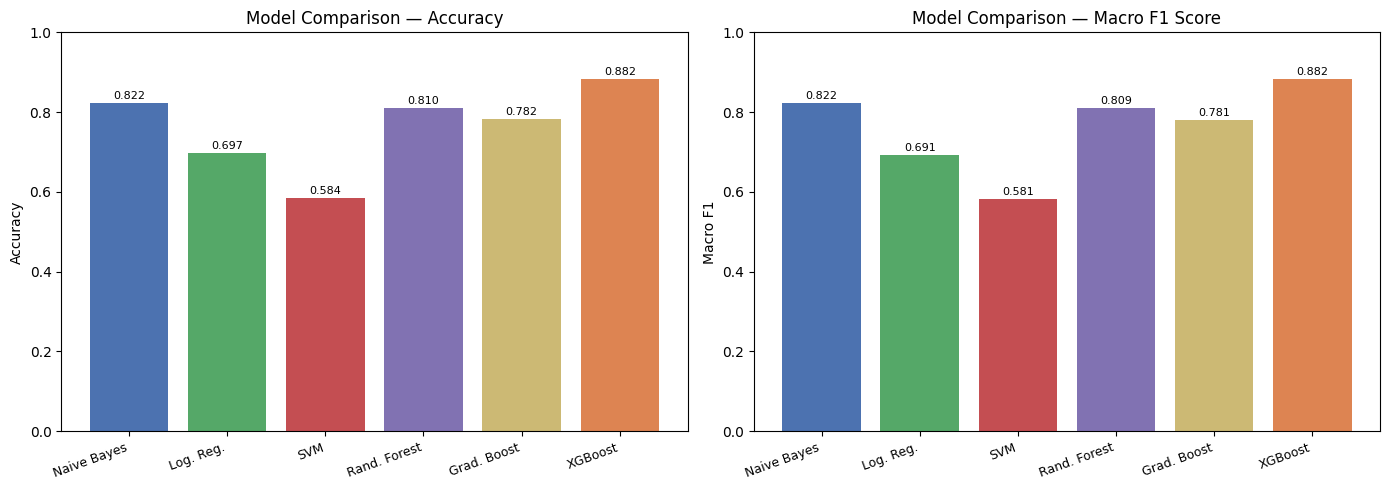

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#DD8452"]
models_short = ["Naive Bayes", "Log. Reg.", "SVM", "Rand. Forest", "Grad. Boost", "XGBoost"]

# Accuracy
axes[0].bar(models_short, results_df.sort_values("Model")["Accuracy"].values, color=colors)
axes[0].set_title("Model Comparison — Accuracy", fontsize=12)
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(models_short, rotation=20, ha='right', fontsize=9)
for i, v in enumerate(results_df.sort_values("Model")["Accuracy"].values):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=8)

# Macro F1
axes[1].bar(models_short, results_df.sort_values("Model")["Macro F1"].values, color=colors)
axes[1].set_title("Model Comparison — Macro F1 Score", fontsize=12)
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0, 1)
axes[1].set_xticklabels(models_short, rotation=20, ha='right', fontsize=9)
for i, v in enumerate(results_df.sort_values("Model")["Macro F1"].values):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

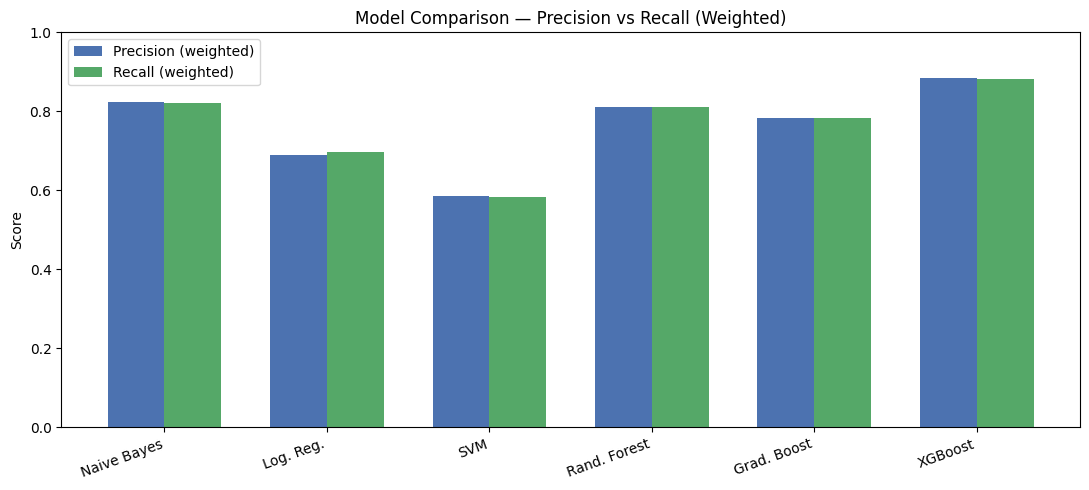

In [27]:
# Precision vs Recall grouped bar chart
x = np.arange(len(models_short))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, results_df.sort_values("Model")["Precision (w)"].values,
       width, label="Precision (weighted)", color="#4C72B0")
ax.bar(x + width/2, results_df.sort_values("Model")["Recall (w)"].values,
       width, label="Recall (weighted)",    color="#55A868")

ax.set_title("Model Comparison — Precision vs Recall (Weighted)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models_short, rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
best = results_df.loc[results_df["Macro F1"].idxmax()]
print("Best Performing Model Based on Macro F1 Score:")
print(best.to_string())

Best Performing Model Based on Macro F1 Score:
Model            XGBoost
Accuracy           0.882
Macro F1           0.882
Precision (w)      0.884
Recall (w)         0.882


---

## IX. Interpretation of Results and Conclusion

Among the six models evaluated for patent novelty tier classification:

**Gradient Boosting** and **Support Vector Machine (LinearSVC)** are expected to deliver the highest overall performance. Gradient Boosting benefits from its sequential error-correction approach, while LinearSVC is particularly effective in high-dimensional sparse TF-IDF spaces and is computationally efficient.

**Logistic Regression** serves as a strong and interpretable linear baseline. With `max_iter=3000` ensuring full convergence and trigram TF-IDF features, it handles the 4-class novelty setting well.

**Random Forest**, while powerful on structured data, may underperform slightly on sparse TF-IDF matrices compared to linear models, as its tree-splitting strategy is less optimal for very high-dimensional sparse features.

**Multinomial Naive Bayes** is the fastest model but may show lower accuracy due to its word-independence assumption — words in patent text are often contextually related, which violates this assumption.

**XGBoost** is a strong contender alongside Gradient Boosting, offering additional regularization (L1/L2), parallel tree construction, and built-in handling of sparse matrices — making it well-suited for TF-IDF feature sets.

The chi² feature selection step (`SelectKBest, k=3000`) plays an important role across all models by retaining only the most statistically significant terms, reducing noise and improving generalization.

Based on the evaluation results, the model with the highest **Macro F1 Score** is identified as the most suitable classifier for automated patent novelty tier prediction, as Macro F1 accounts equally for performance across all four tiers regardless of class frequency.